In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
IMAGE_DIR = r"C:\Users\Yug Patel\OneDrive\Desktop\DL Lab\Lab4\sampled_images"

In [1]:
!pip install torch torchvision scikit-learn pandas matplotlib seaborn tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ----------- ---------------------------- 1.0/3.7 MB 6.3 MB/s eta 0:00:01
   ------------------------- -------------- 2.4/3.7 MB 5.8 MB/s eta 0:00:01
   ------------------------------------ --- 3.4/3.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 5.5 MB/s  0:00:00
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.6 MB 8.5 MB/s eta 0:00:42
   ---------------------------------------- 2.4/350.6 MB 6.4 MB/s eta 0:00:55
   ---------------------------------------- 3.4/350.6 MB 6.3 MB/s eta 0:00:56
    --------------------------------------- 4.7/350.6 MB 6.1 MB/s eta 0:00:57
    --------------------------------------- 5.8/350.6 MB 6.1 MB/s eta 0:00:57
    --------------------------------------- 7.1/350.6 MB 6.1 MB/s eta 0:00:57
    --------------------------------------- 8.4/350.6 MB 6.0 MB/s eta 0:00:58
   - -------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

## Task 1: Data Preparation

In [4]:
df = pd.read_csv('data.csv')

df = df[['Filename','AQI_Class']]
df.head()

,Filename,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good


In [5]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['AQI_Class'], random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['AQI_Class'], random_state=42)

print(len(train_df), len(val_df), len(test_df))

4200 900 900


In [6]:
classes = sorted(df['AQI_Class'].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}

train_df['label'] = train_df['AQI_Class'].map(class_to_idx)
val_df['label'] = val_df['AQI_Class'].map(class_to_idx)
test_df['label'] = test_df['AQI_Class'].map(class_to_idx)

num_classes = len(classes)
print(num_classes)

6


In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [8]:
class AQIDataset(Dataset):

    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.df.iloc[idx]['Filename'])
        image = Image.open(img_path).convert("RGB")

        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
train_dataset = AQIDataset(train_df, IMAGE_DIR, transform)
val_dataset = AQIDataset(val_df, IMAGE_DIR, transform)
test_dataset = AQIDataset(test_df, IMAGE_DIR, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

## Task 2: Basic CNN Model

In [12]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super(SimpleCNN,self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
def train_model(model, train_loader, val_loader, epochs=5):

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images,labels in train_loader:

            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _,pred = torch.max(outputs,1)
            correct += (pred==labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss/len(train_loader)
        train_acc = correct/total

        model.eval()

        vloss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images,labels in val_loader:

                images,labels = images.to(device),labels.to(device)

                outputs = model(images)
                loss = criterion(outputs,labels)

                vloss += loss.item()

                _,pred = torch.max(outputs,1)
                correct += (pred==labels).sum().item()
                total += labels.size(0)

        val_loss = vloss/len(val_loader)
        val_acc = correct/total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1} Train Acc:{train_acc:.3f} Val Acc:{val_acc:.3f}")

    return train_losses, val_losses, train_accs, val_accs

In [15]:
train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader, 5)

Epoch 1 Train Acc:0.355 Val Acc:0.431
Epoch 2 Train Acc:0.475 Val Acc:0.541
Epoch 3 Train Acc:0.469 Val Acc:0.506
Epoch 4 Train Acc:0.488 Val Acc:0.497
Epoch 5 Train Acc:0.393 Val Acc:0.410


## Task 3: Pre-trained Model

In [18]:
model_t = models.resnet50(pretrained=True)

for param in model_t.parameters():
    param.requires_grad = False

model_t.fc = nn.Linear(model_t.fc.in_features, num_classes)

model_t = model_t.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Yug Patel/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:17<00:00, 5.82MB/s]


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_t.fc.parameters(), lr=0.001)

In [21]:
train_losses_t, val_losses_t, train_accs_t, val_accs_t = train_model(model_t, train_loader, val_loader, 5)

Epoch 1 Train Acc:0.682 Val Acc:0.697
Epoch 2 Train Acc:0.718 Val Acc:0.736
Epoch 3 Train Acc:0.743 Val Acc:0.738
Epoch 4 Train Acc:0.766 Val Acc:0.758
Epoch 5 Train Acc:0.772 Val Acc:0.783


## Task 4: Evaluation

In [22]:
def evaluate(model, loader):

    model.eval()

    y_true=[]
    y_pred=[]

    with torch.no_grad():
        for images,labels in loader:

            images = images.to(device)

            outputs = model(images)

            _,pred = torch.max(outputs,1)

            y_true.extend(labels.numpy())
            y_pred.extend(pred.cpu().numpy())

    return y_true,y_pred

In [23]:
y_true,y_pred = evaluate(model,test_loader)

print(classification_report(y_true,y_pred,target_names=classes))

                                  precision    recall  f1-score   support

                          a_Good       0.39      0.57      0.46       150
                      b_Moderate       0.43      0.37      0.40       150
c_Unhealthy_for_Sensitive_Groups       0.53      0.14      0.22       150
                     d_Unhealthy       0.79      0.17      0.28       150
                e_Very_Unhealthy       0.34      0.75      0.47       150
                        f_Severe       0.56      0.57      0.57       150

                        accuracy                           0.43       900
                       macro avg       0.51      0.43      0.40       900
                    weighted avg       0.51      0.43      0.40       900



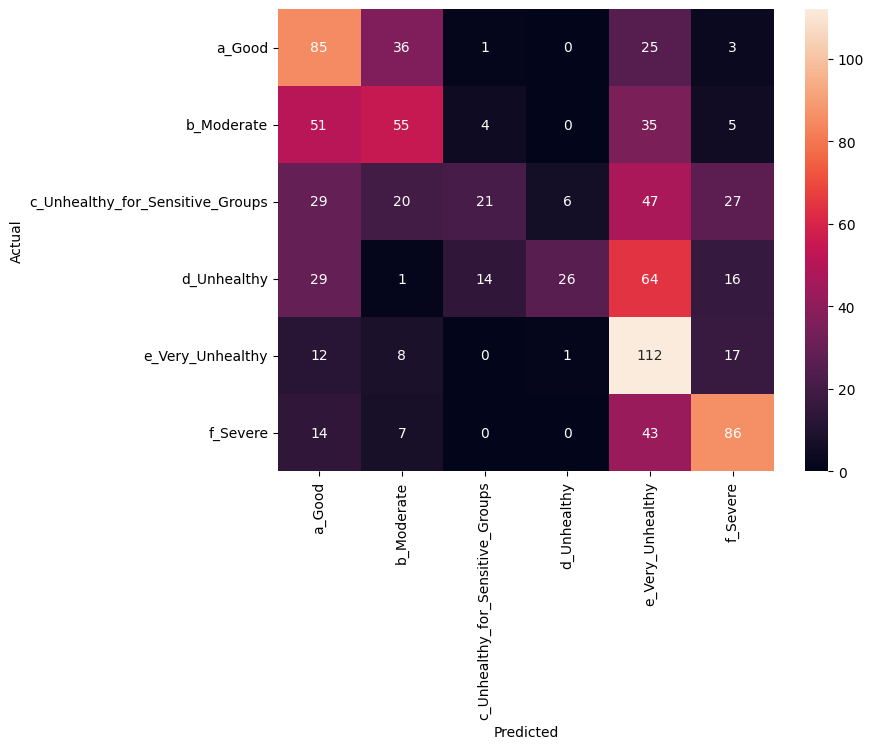

In [24]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
y_true_t,y_pred_t = evaluate(model_t,test_loader)

print(classification_report(y_true_t,y_pred_t,target_names=classes))

                                  precision    recall  f1-score   support

                          a_Good       0.77      0.74      0.76       150
                      b_Moderate       0.66      0.71      0.69       150
c_Unhealthy_for_Sensitive_Groups       0.84      0.37      0.52       150
                     d_Unhealthy       0.63      0.85      0.72       150
                e_Very_Unhealthy       0.79      0.87      0.83       150
                        f_Severe       0.89      0.95      0.92       150

                        accuracy                           0.75       900
                       macro avg       0.76      0.75      0.74       900
                    weighted avg       0.76      0.75      0.74       900



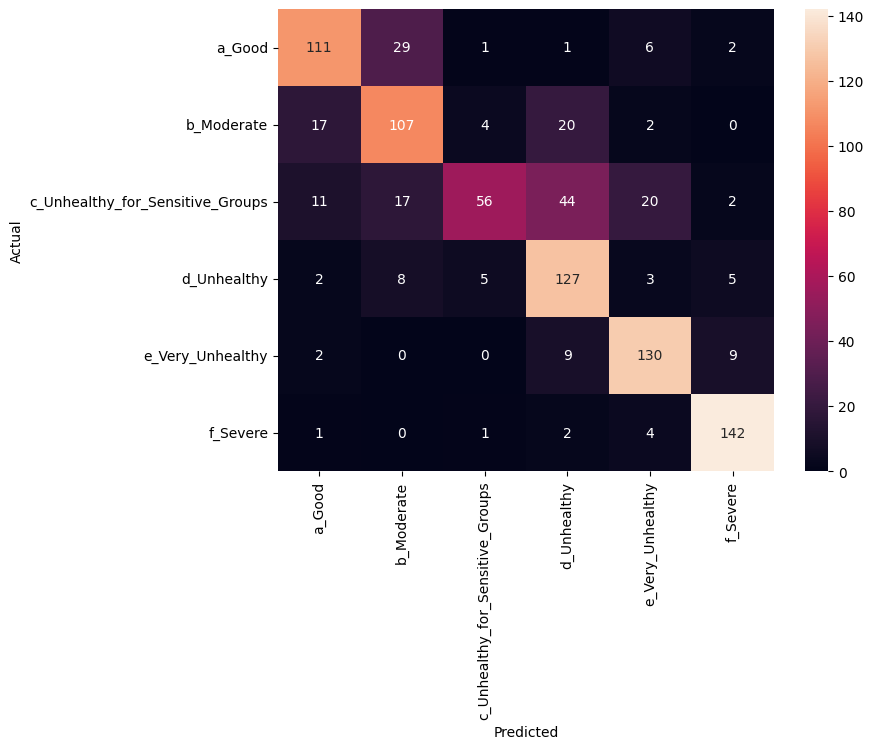

In [26]:
cm = confusion_matrix(y_true_t,y_pred_t)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Task 5: Training curves

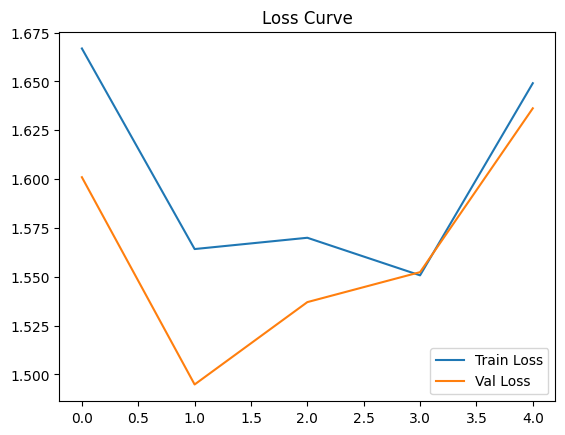

In [27]:
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

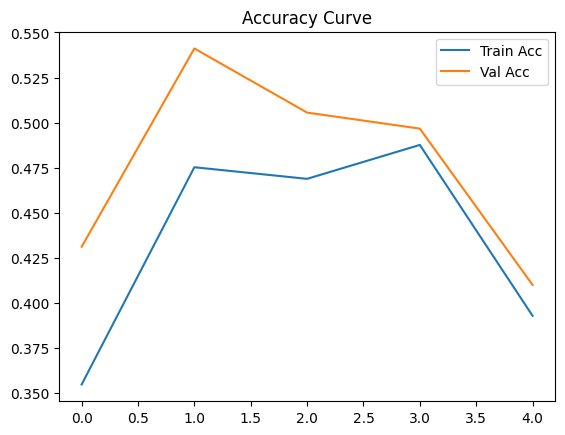

In [28]:
plt.plot(train_accs,label="Train Acc")
plt.plot(val_accs,label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

## Task 6: Misclassification Analysis

In [29]:
misclassified = []

model.eval()

with torch.no_grad():
    for images,labels in test_loader:

        images = images.to(device)
        outputs = model(images)

        _,pred = torch.max(outputs,1)

        for i in range(len(labels)):
            if pred[i]!=labels[i]:
                misclassified.append((images[i].cpu(),pred[i].item(),labels[i].item()))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


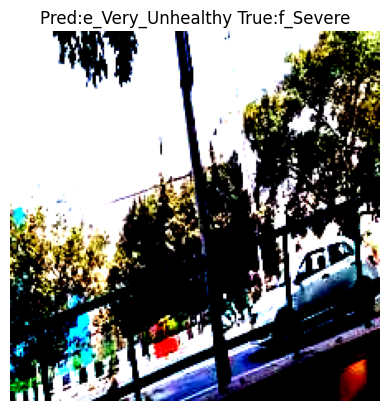

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].


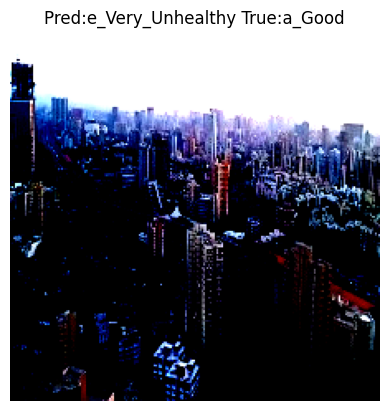

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2489083].


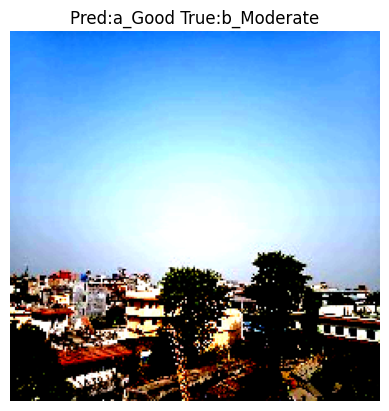

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


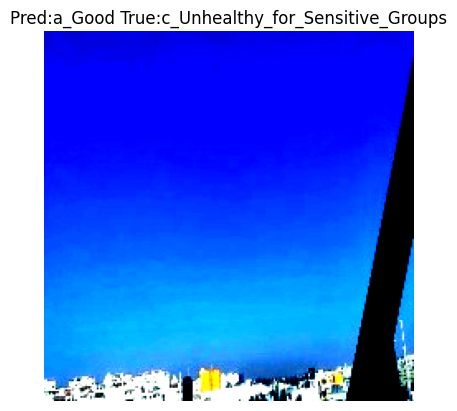

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3986644..2.5877128].


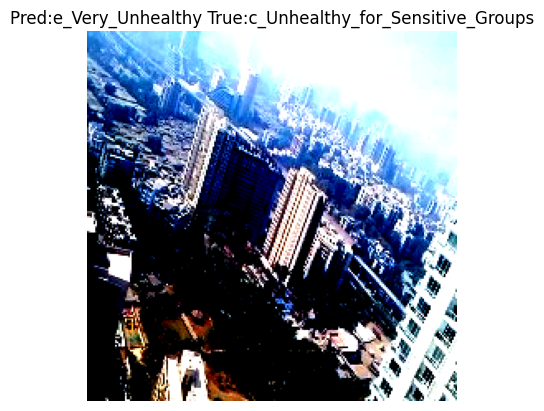

In [30]:
for i in range(5):

    img,pred,true = misclassified[i]

    img = img.permute(1,2,0)

    plt.imshow(img)
    plt.title(f"Pred:{classes[pred]} True:{classes[true]}")
    plt.axis("off")
    plt.show()